<a href="https://colab.research.google.com/github/mohamadarif03/11-Mohamad_Arif-Sheyla_Natasha/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [266]:
import kagglehub

path = kagglehub.dataset_download("mexwell/motor-vehicle-insurance-portfolio")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'motor-vehicle-insurance-portfolio' dataset.
Path to dataset files: /kaggle/input/motor-vehicle-insurance-portfolio


In [267]:
import os
os.listdir(path)

['Descriptive of the variables.xlsx',
 'sample type claim.csv',
 'Motor vehicle insurance data.csv']

In [268]:
df = pd.read_csv(path + "/Motor vehicle insurance data.csv", sep=";")
df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


In [269]:
df.columns

Index(['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
       'Date_birth', 'Date_driving_licence', 'Distribution_channel',
       'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products',
       'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year',
       'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk',
       'Area', 'Second_driver', 'Year_matriculation', 'Power',
       'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length',
       'Weight'],
      dtype='object')

In [270]:
df.describe()

,ID,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,...,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,...,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,95226.000000,105555.000000
mean,26271.286789,0.451310,6.696604,1.455649,1.837232,1.065842,0.221837,0.319180,315.892557,153.557305,...,2.721804,0.273895,0.123708,2004.728038,92.682611,1617.759367,18413.657243,4.067898,4.252007,1191.262422
std,15388.309324,0.497626,6.263911,0.928427,1.155536,0.267807,0.464858,0.466161,140.927969,1477.112362,...,0.614835,0.445958,0.329250,6.767037,37.012645,604.697382,9135.074235,1.511839,0.393220,458.081834
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.140000,0.000000,...,1.000000,0.000000,0.000000,1950.000000,0.000000,49.000000,270.460000,0.000000,1.978000,43.000000
25%,12925.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,241.610000,0.000000,...,3.000000,0.000000,0.000000,2001.000000,75.000000,1390.000000,13127.210000,3.000000,3.999000,1043.000000
50%,26082.000000,0.000000,4.000000,1.000000,2.000000,1.000000,0.000000,0.000000,292.280000,0.000000,...,3.000000,0.000000,0.000000,2005.000000,90.000000,1598.000000,17608.770000,5.000000,4.230000,1205.000000
75%,39754.000000,1.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,361.640000,0.000000,...,3.000000,1.000000,0.000000,2008.000000,110.000000,1910.000000,22595.000000,5.000000,4.443000,1388.000000
max,53502.000000,1.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,260853.240000,...,4.000000,1.000000,1.000000,2018.000000,580.000000,7480.000000,220675.800000,6.000000,8.218000,7300.000000


In [271]:
df.shape

(105555, 30)

In [272]:
print(f"Jumlah kolom numerik: {df.select_dtypes(include='number').shape[1]}")
print(f"Jumlah kolom kategorikal: {df.select_dtypes(include='object').shape[1]}")

Jumlah kolom numerik: 23
Jumlah kolom kategorikal: 7


### Convert string into datetime on 6 columns

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    105555 non-null  int64  
 1   Date_start_contract   105555 non-null  object 
 2   Date_last_renewal     105555 non-null  object 
 3   Date_next_renewal     105555 non-null  object 
 4   Date_birth            105555 non-null  object 
 5   Date_driving_licence  105555 non-null  object 
 6   Distribution_channel  105555 non-null  int64  
 7   Seniority             105555 non-null  int64  
 8   Policies_in_force     105555 non-null  int64  
 9   Max_policies          105555 non-null  int64  
 10  Max_products          105555 non-null  int64  
 11  Lapse                 105555 non-null  int64  
 12  Date_lapse            35147 non-null   object 
 13  Payment               105555 non-null  int64  
 14  Premium               105555 non-null  float64
 15  

In [274]:
date_columns = ['Date_lapse', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence']
df[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Date_lapse            35147 non-null   object
 1   Date_start_contract   105555 non-null  object
 2   Date_last_renewal     105555 non-null  object
 3   Date_next_renewal     105555 non-null  object
 4   Date_birth            105555 non-null  object
 5   Date_driving_licence  105555 non-null  object
dtypes: object(6)
memory usage: 4.8+ MB


In [275]:
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y")

df["Date_lapse"].dtype

dtype('<M8[ns]')

In [276]:
df[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Date_lapse            35147 non-null   datetime64[ns]
 1   Date_start_contract   105555 non-null  datetime64[ns]
 2   Date_last_renewal     105555 non-null  datetime64[ns]
 3   Date_next_renewal     105555 non-null  datetime64[ns]
 4   Date_birth            105555 non-null  datetime64[ns]
 5   Date_driving_licence  105555 non-null  datetime64[ns]
dtypes: datetime64[ns](6)
memory usage: 4.8 MB


In [277]:
df_kategorikal = df.select_dtypes(include='object')
df_numerik = df.select_dtypes(include='number')
df_datetime = df.select_dtypes(include='datetime64[ns]')

print(f"Kolom kategorikal: {df_kategorikal.columns.tolist()}")
print(f"Kolom numerik: {df_numerik.columns.tolist()}")
print(f"Kolom datetime: {df_datetime.columns.tolist()}")

Kolom kategorikal: ['Type_fuel']
Kolom numerik: ['ID', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Length', 'Weight']
Kolom datetime: ['Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Date_lapse']


### Check Null

In [278]:
df_all_null = df.isnull().sum()

df_all_null = df_all_null[df_all_null > 0]

df_all_null

,0
Date_lapse,70408
Type_fuel,1764
Length,10329


### Check Duplicates

In [279]:
df.duplicated().sum()

np.int64(0)

### Check number of unique values

In [280]:
df.nunique()

,0
ID,53502
Date_start_contract,5518
Date_last_renewal,1124
Date_next_renewal,1124
Date_birth,17048
Date_driving_licence,14016
Distribution_channel,2
Seniority,40
Policies_in_force,17
Max_policies,17


In [281]:
df_all_unique = df.nunique()
df_all_unique = df_all_unique[df_all_unique < 10].drop(["N_doors", "Max_products"], axis=0)
df_all_unique

,0
Distribution_channel,2
Lapse,8
Payment,2
Type_risk,4
Area,2
Second_driver,2
Type_fuel,2


# Visualisasi

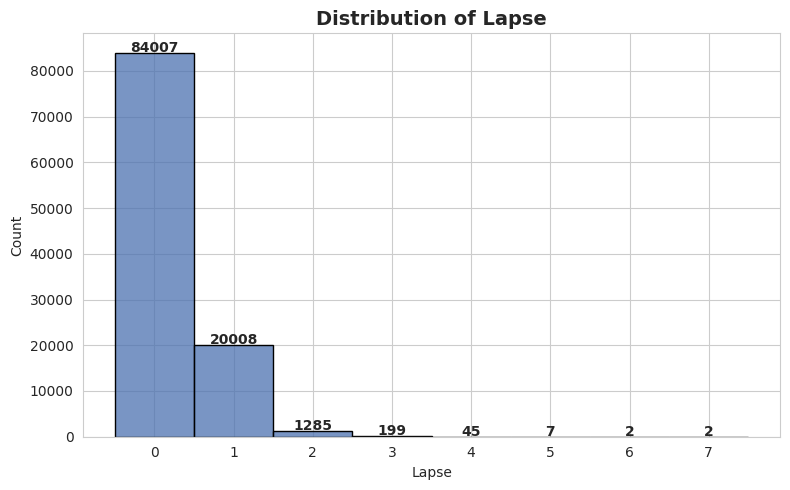

In [282]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

ax = sns.histplot(
    x="Lapse",
    data=df,
    discrete=True,
    color="#4C72B0",
    edgecolor="black"
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 200,
            int(height),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title("Distribution of Lapse", fontsize=14, fontweight="bold")
plt.xlabel("Lapse")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**Change Lapse into Binary Label**

In [283]:
df['Target'] = (df['Lapse'] > 0).astype(int)

In [284]:
df[df["Date_lapse"].isna() & (df["Target"] == 1)].shape #jumlah actual null

(2376, 31)

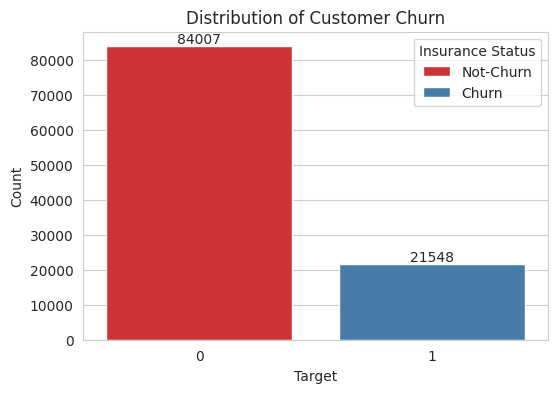

In [285]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Target', data=df, palette='Set1')

for container in ax.containers:
    ax.bar_label(container)

ax.legend(labels=["Not-Churn", "Churn"], title="Insurance Status")

plt.title("Distribution of Customer Churn")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

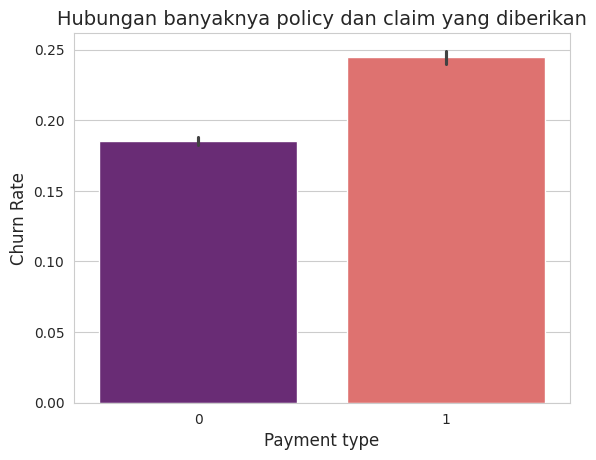

In [328]:
sns.barplot(x='Payment', y='Target', data=df, palette='magma')
plt.title('Hubungan banyaknya policy dan claim yang diberikan', fontsize=14)
plt.xlabel('Payment type', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.show()

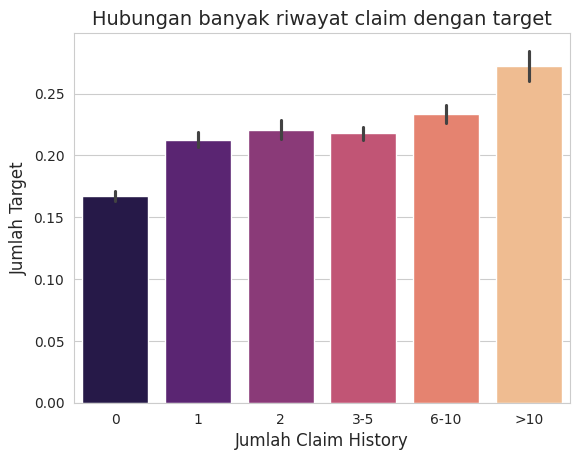

In [331]:
claim_group = pd.cut(
    df['N_claims_history'],
    bins=[-1,0,1,2,5,10,100],
    labels=['0','1','2','3-5','6-10','>10']
)
sns.barplot(x=claim_group, y=df['Target'], palette='magma')
plt.title('Hubungan banyak riwayat claim dengan target', fontsize=14)
plt.xlabel('Jumlah Claim History', fontsize=12)
plt.ylabel('Jumlah Target', fontsize=12)
plt.show()

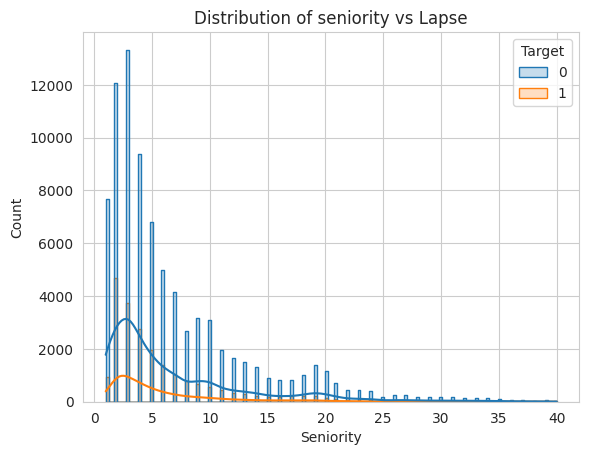

In [286]:
sns.histplot(data=df, x='Seniority', hue='Target', kde=True, element="step")
plt.title("Distribution of seniority vs Lapse")
plt.show()

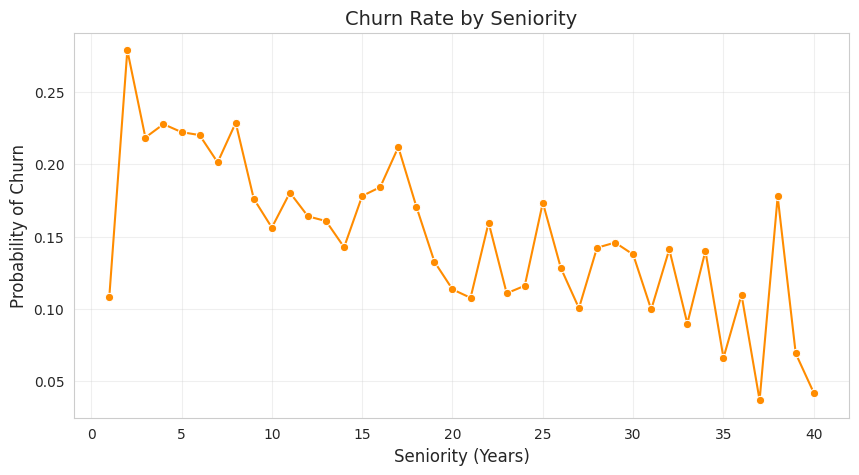

In [287]:
# 1. Group by Seniority and calculate the mean of the Target (Churn Rate)
churn_rate_by_seniority = df.groupby('Seniority')['Target'].mean()

# 2. Plot as a line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=churn_rate_by_seniority, marker='o', color='darkorange')

plt.title('Churn Rate by Seniority', fontsize=14)
plt.ylabel('Probability of Churn', fontsize=12)
plt.xlabel('Seniority (Years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

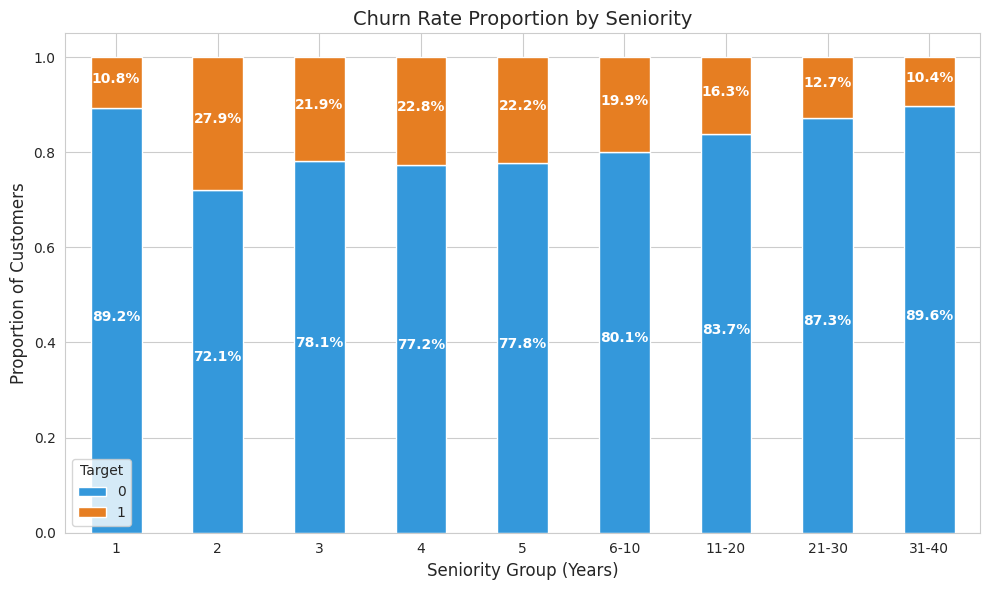

In [288]:
df['Seniority_bin'] = pd.cut(
    df['Seniority'],
    bins=[0, 1, 2, 3, 4, 5, 10, 20, 30, 40],
    labels=['1', '2', '3', '4', '5', '6-10', '11-20', '21-30', '31-40']
)

analysis = pd.crosstab(df['Seniority_bin'], df['Target'], normalize='index')

# 3. Plot the 100% Stacked Bar
analysis.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#3498db', '#e67e22'])

plt.title('Churn Rate Proportion by Seniority', fontsize=14)
plt.xlabel('Seniority Group (Years)', fontsize=12)
plt.ylabel('Proportion of Customers', fontsize=12)
plt.xticks(rotation=0)

for n, x in enumerate([*analysis.index.values]):
    for (proportion, y_loc) in zip(analysis.loc[x], analysis.loc[x].cumsum()):
        plt.text(x=n,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%',
                 color="white", fontsize=10, fontweight="bold", ha="center")

plt.tight_layout()
plt.show()

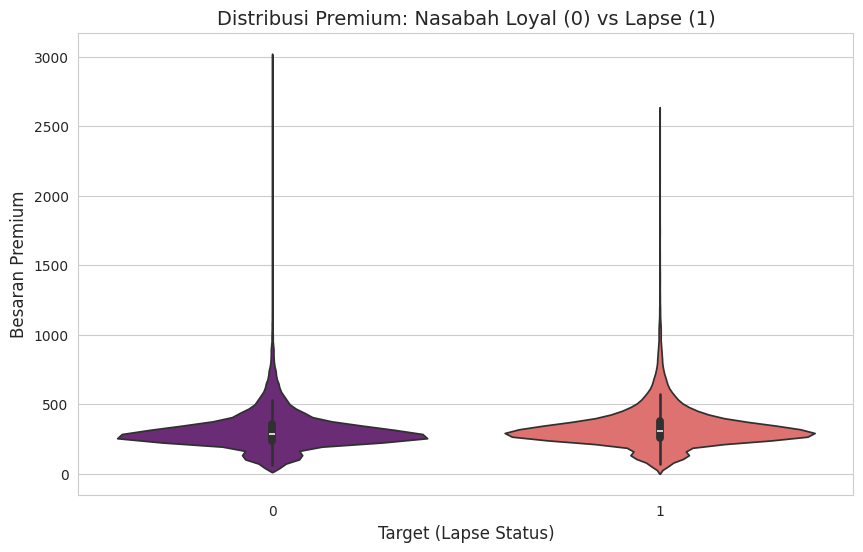

In [289]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Target', y='Premium', data=df, palette='magma')

plt.title('Distribusi Premium: Nasabah Loyal (0) vs Lapse (1)', fontsize=14)
plt.xlabel('Target (Lapse Status)', fontsize=12)
plt.ylabel('Besaran Premium', fontsize=12)
plt.show()

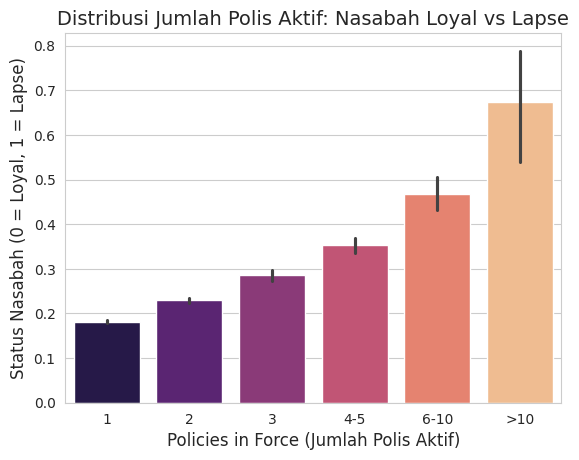

In [290]:
df['policy_group'] = pd.cut(
    df['Policies_in_force'],
    bins=[0,1,2,3,5,10,20],
    labels=['1','2','3','4-5','6-10','>10']
)

sns.barplot(x='policy_group', y='Target', data=df, palette='magma')
plt.title('Distribusi Jumlah Polis Aktif: Nasabah Loyal vs Lapse', fontsize=14)
plt.xlabel('Policies in Force (Jumlah Polis Aktif)', fontsize=12)
plt.ylabel('Status Nasabah (0 = Loyal, 1 = Lapse)', fontsize=12)
plt.show()

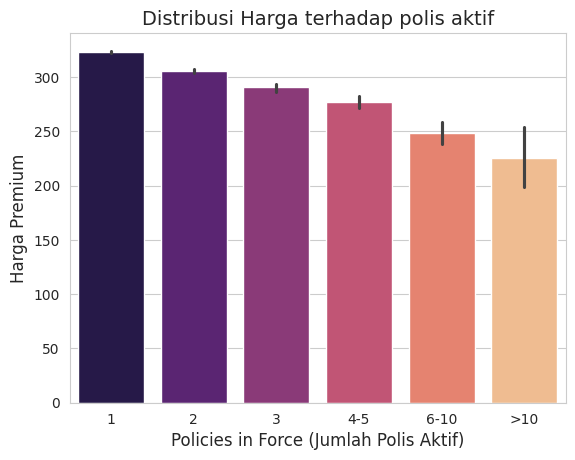

In [291]:
sns.barplot(x='policy_group', y='Premium', data=df, palette='magma')
plt.title('Distribusi Harga terhadap polis aktif', fontsize=14)
plt.xlabel('Policies in Force (Jumlah Polis Aktif)', fontsize=12)
plt.ylabel('Harga Premium', fontsize=12)
plt.show()

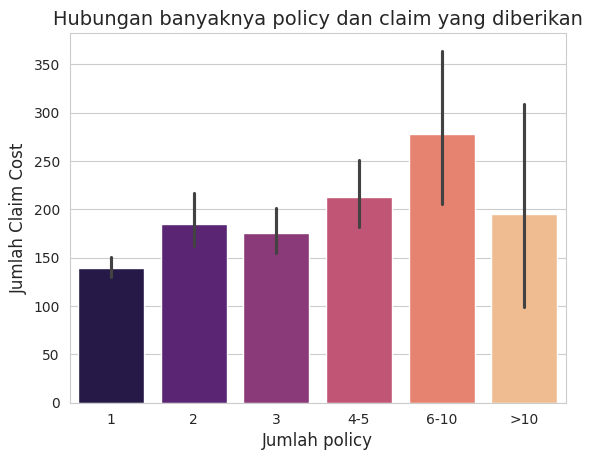

In [292]:
sns.barplot(x='policy_group', y='Cost_claims_year', data=df, palette='magma')
plt.title('Hubungan banyaknya policy dan claim yang diberikan', fontsize=14)
plt.xlabel('Jumlah policy', fontsize=12)
plt.ylabel('Jumlah Claim Cost', fontsize=12)
plt.show()

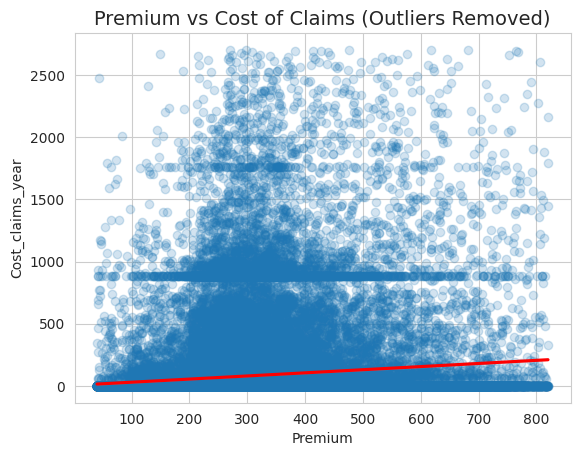

In [293]:
q_premium = df['Premium'].quantile(0.99)
q_cost = df['Cost_claims_year'].quantile(0.99)

# Filter the dataframe to exclude the top 1%
df_filtered = df[(df['Premium'] <= q_premium) & (df['Cost_claims_year'] <= q_cost)]

# Plot the filtered data
sns.regplot(x='Premium', y='Cost_claims_year', data=df_filtered,
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})

plt.title('Premium vs Cost of Claims (Outliers Removed)', fontsize=14)
plt.show()

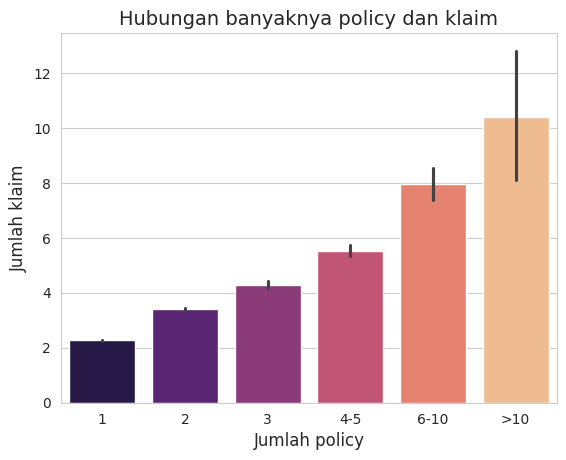

In [294]:
sns.barplot(x='policy_group', y='N_claims_history', data=df, palette='magma')
plt.title('Hubungan banyaknya policy dan klaim', fontsize=14)
plt.xlabel('Jumlah policy', fontsize=12)
plt.ylabel('Jumlah klaim', fontsize=12)
plt.show()

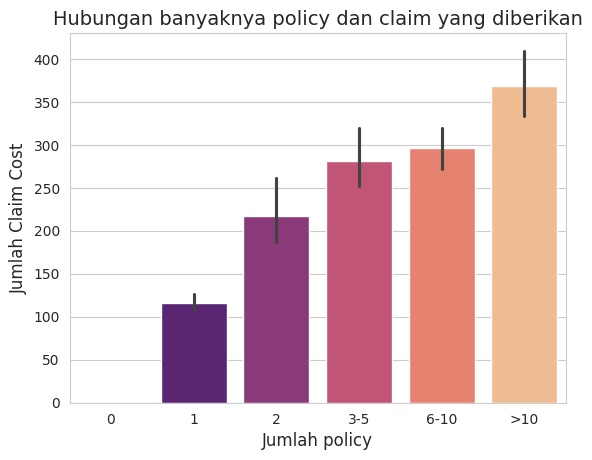

In [296]:
df['claim_group'] = pd.cut(
    df['N_claims_history'],
    bins=[-1,0,1,2,5,10,100],
    labels=['0','1','2','3-5','6-10','>10']
)

sns.barplot(x='claim_group', y='Cost_claims_year', data=df, palette='magma')
plt.title('Hubungan banyaknya policy dan claim yang diberikan', fontsize=14)
plt.xlabel('Jumlah policy', fontsize=12)
plt.ylabel('Jumlah Claim Cost', fontsize=12)
plt.show()

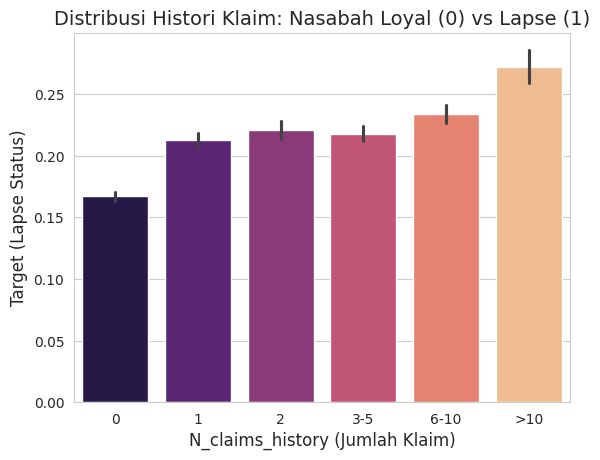

In [297]:
sns.barplot(x='claim_group', y='Target', data=df, palette='magma')
plt.title('Distribusi Histori Klaim: Nasabah Loyal (0) vs Lapse (1)', fontsize=14)
plt.xlabel('N_claims_history (Jumlah Klaim)', fontsize=12)
plt.ylabel('Target (Lapse Status)', fontsize=12)
plt.show()

<Axes: xlabel='claim_group', ylabel='Premium'>

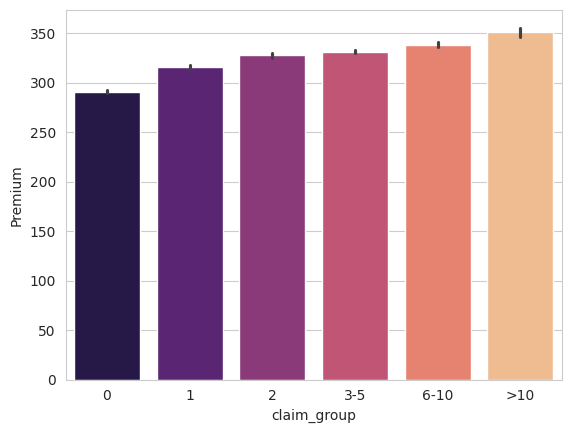

In [298]:
sns.barplot(x='claim_group', y='Premium', data=df, palette='magma')

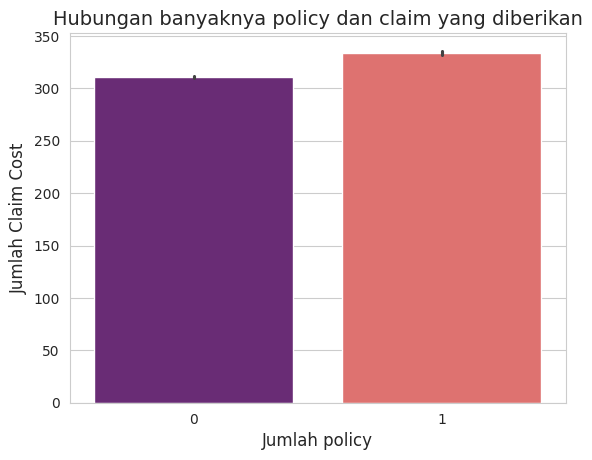

In [299]:
sns.barplot(x='Target', y='Premium', data=df, palette='magma')
plt.title('Hubungan banyaknya policy dan claim yang diberikan', fontsize=14)
plt.xlabel('Jumlah policy', fontsize=12)
plt.ylabel('Jumlah Claim Cost', fontsize=12)
plt.show()

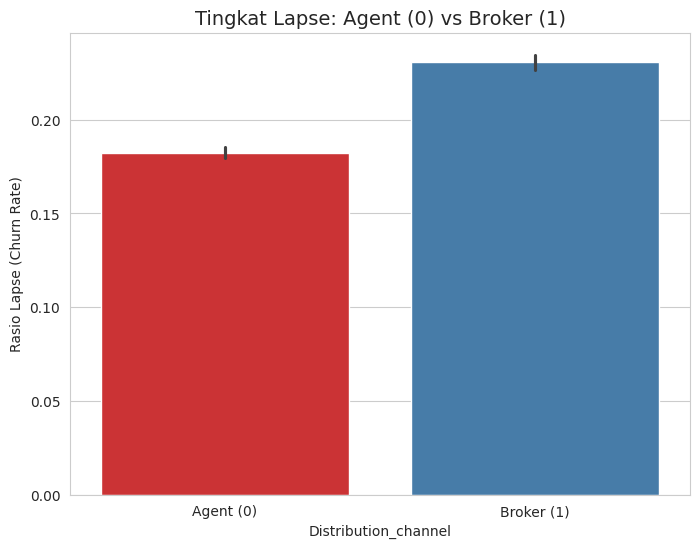

In [300]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Distribution_channel', y='Target', palette='Set1')

plt.title('Tingkat Lapse: Agent (0) vs Broker (1)', fontsize=14)
plt.xticks([0, 1], ['Agent (0)', 'Broker (1)'])
plt.ylabel('Rasio Lapse (Churn Rate)')
plt.show()

<Figure size 800x600 with 0 Axes>

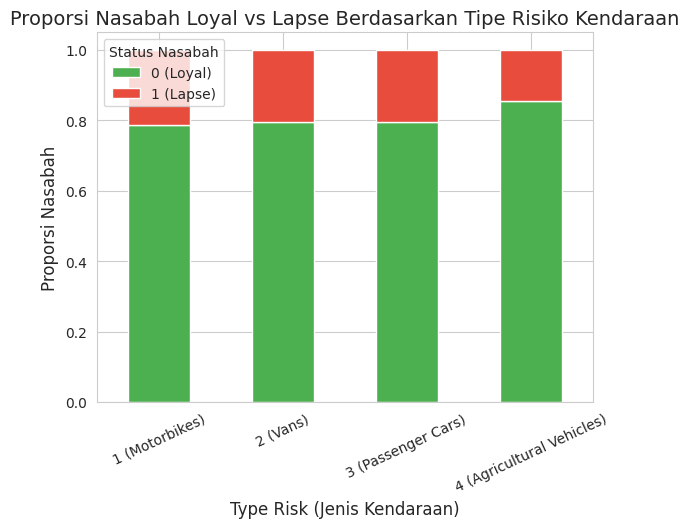

In [301]:
plt.figure(figsize=(8,6))

risk_labels = {
    1: '1 (Motorbikes)',
    2: '2 (Vans)',
    3: '3 (Passenger Cars)',
    4: '4 (Agricultural Vehicles)'
}

(pd.crosstab(df['Type_risk'], df['Target'], normalize='index')
   .rename(index=risk_labels)
   .plot(kind='bar', stacked=True, color=['#4CAF50','#E74C3C']))

plt.title('Proporsi Nasabah Loyal vs Lapse Berdasarkan Tipe Risiko Kendaraan', fontsize=14)
plt.xlabel('Type Risk (Jenis Kendaraan)', fontsize=12)
plt.ylabel('Proporsi Nasabah', fontsize=12)

plt.legend(title='Status Nasabah', labels=['0 (Loyal)', '1 (Lapse)'])
plt.xticks(rotation=25)
plt.show()

<Figure size 800x600 with 0 Axes>

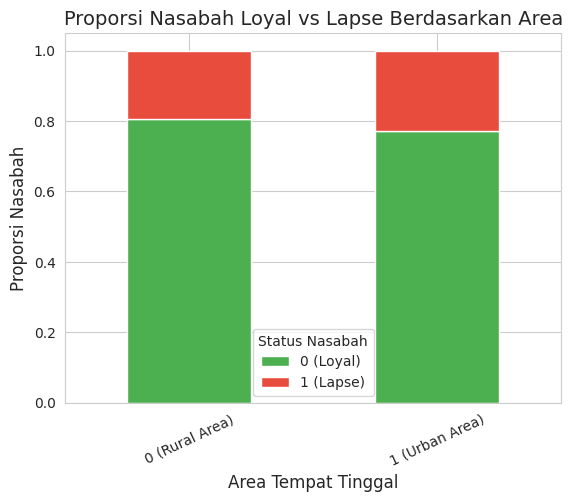

In [302]:
plt.figure(figsize=(8,6))

area_labels = {
    0: '0 (Rural Area)',
    1: '1 (Urban Area)'
}

(pd.crosstab(df['Area'], df['Target'], normalize='index')
   .rename(index=area_labels)
   .plot(kind='bar', stacked=True, color=['#4CAF50','#E74C3C']))

plt.title('Proporsi Nasabah Loyal vs Lapse Berdasarkan Area', fontsize=14)
plt.xlabel('Area Tempat Tinggal', fontsize=12)
plt.ylabel('Proporsi Nasabah', fontsize=12)

plt.legend(title='Status Nasabah', labels=['0 (Loyal)', '1 (Lapse)'])

plt.xticks(rotation=25)

plt.show()

In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    105555 non-null  int64         
 1   Date_start_contract   105555 non-null  datetime64[ns]
 2   Date_last_renewal     105555 non-null  datetime64[ns]
 3   Date_next_renewal     105555 non-null  datetime64[ns]
 4   Date_birth            105555 non-null  datetime64[ns]
 5   Date_driving_licence  105555 non-null  datetime64[ns]
 6   Distribution_channel  105555 non-null  int64         
 7   Seniority             105555 non-null  int64         
 8   Policies_in_force     105555 non-null  int64         
 9   Max_policies          105555 non-null  int64         
 10  Max_products          105555 non-null  int64         
 11  Lapse                 105555 non-null  int64         
 12  Date_lapse            35147 non-null   datetime64[ns]
 13 

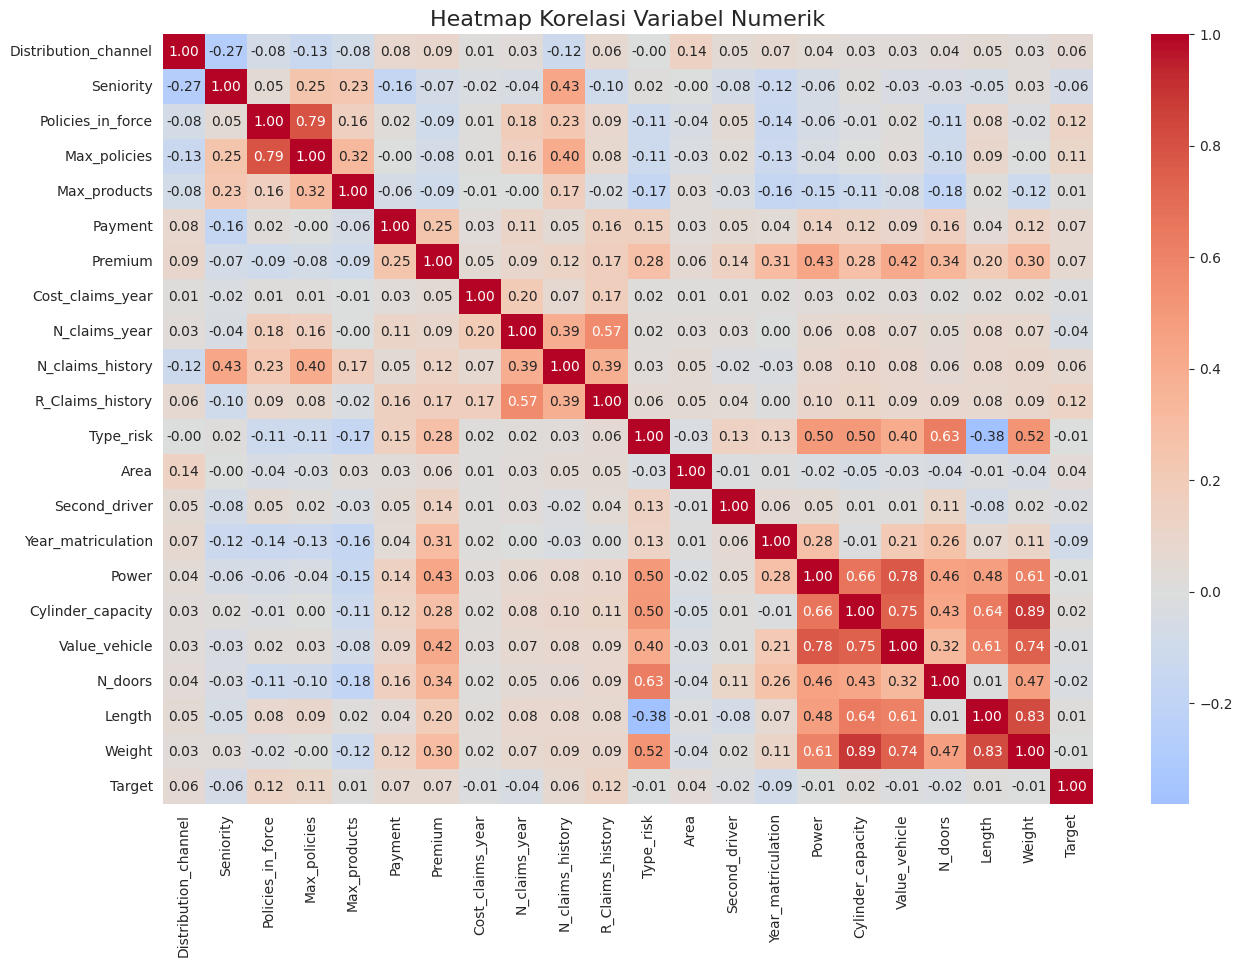

In [304]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID', 'Lapse'], errors='ignore')

plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Heatmap Korelasi Variabel Numerik', fontsize=16)
plt.show()

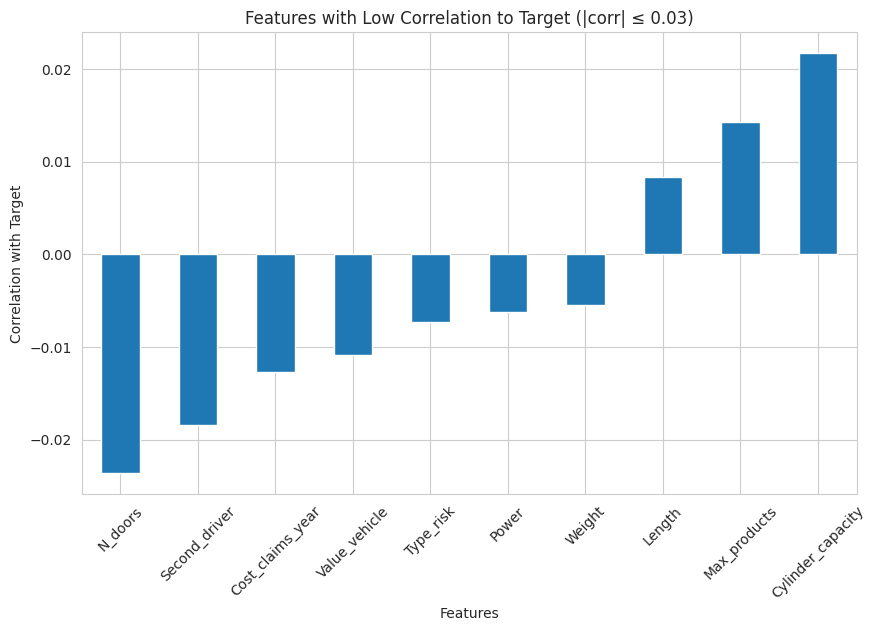

In [340]:
# select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# correlation with target
corr_target = numeric_df.corr()["Target"]

# filter correlation near 0
low_corr = corr_target[(corr_target <= 0.03) & (corr_target >= -0.03)]

plt.figure(figsize=(10,6))
low_corr.sort_values().plot(kind='bar')

plt.title("Features with Low Correlation to Target (|corr| ≤ 0.03)")
plt.ylabel("Correlation with Target")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

In [342]:
low_corr_cols = low_corr.index.tolist()
low_corr_cols

['Max_products',
 'Cost_claims_year',
 'Type_risk',
 'Second_driver',
 'Power',
 'Cylinder_capacity',
 'Value_vehicle',
 'N_doors',
 'Length',
 'Weight']

### date visualization

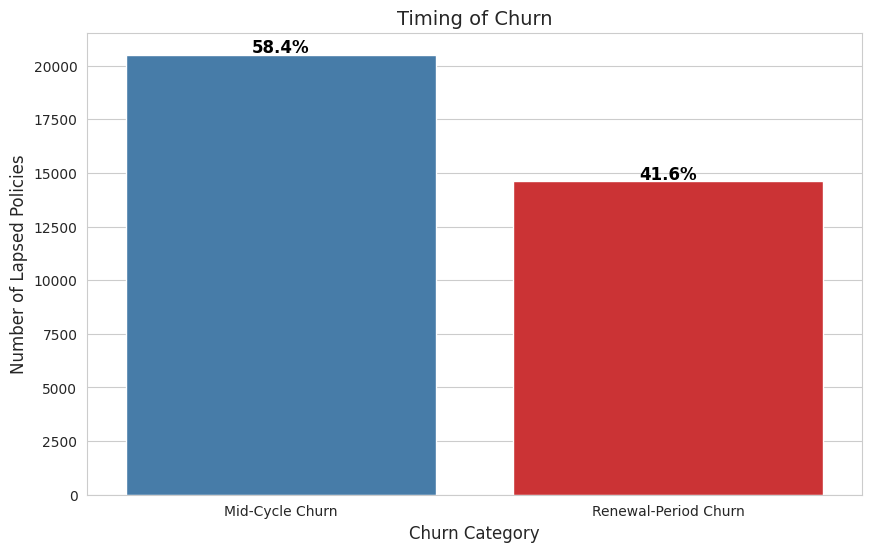

In [338]:
lapsed_df = df[df['Date_lapse'].notna()].copy()

# 3. Calculate the gap in days
lapsed_df['days_from_renewal'] = (lapsed_df['Date_lapse'] - lapsed_df['Date_last_renewal']).dt.days

# 4. Create the Category
lapsed_df['Churn_Type'] = np.where(
    np.abs(lapsed_df['days_from_renewal']) <= 30,
    'Renewal-Period Churn',
    'Mid-Cycle Churn'
)

# 5. Visualization
plt.figure(figsize=(10, 6))
colors = ['#377EB8', '#E41A1C']
sns.countplot(x='Churn_Type', data=lapsed_df, palette=colors)

# Add percentage labels
total = len(lapsed_df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points', fontweight='bold')

plt.title('Timing of Churn', fontsize=14)
plt.xlabel('Churn Category', fontsize=12)
plt.ylabel('Number of Lapsed Policies', fontsize=12)
plt.show()

In [343]:
cols_to_drop = [
    'ID',
    'Lapse',
    'Date_birth',
    'Cylinder_capacity',
    'Weight',
    'Length',
    'N_doors',
    'Power',
    'Second_driver',
    'Max_products',
    'Value_vehicle',
    'Max_policies',
    'N_doors',
    'Cost_claims_year'
]

df_model = df.drop(columns=cols_to_drop)

In [344]:
df_model.shape

(105555, 22)

In [346]:
df_model.columns

Index(['Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
       'Date_driving_licence', 'Distribution_channel', 'Seniority',
       'Policies_in_force', 'Date_lapse', 'Payment', 'Premium',
       'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk',
       'Area', 'Year_matriculation', 'Type_fuel', 'Target', 'Seniority_bin',
       'policy_group', 'claim_group', 'Churn_Type'],
      dtype='object')

In [345]:
df_model.isnull().sum()

,0
Date_start_contract,0
Date_last_renewal,0
Date_next_renewal,0
Date_driving_licence,0
Distribution_channel,0
Seniority,0
Policies_in_force,0
Date_lapse,70408
Payment,0
Premium,0
